In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["KERAS_BACKEND"] = "torch"
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')


In [1]:
import yfinance as yf
import datetime as dt

# FAANG stocks tickers
stock = ['AAPL', 'AMZN', 'META', 'NFLX', 'GOOGL']

start = dt.datetime(2020, 1, 1)
end = dt.datetime(2026, 1, 1)

df = yf.download(stock, start, end)

/tmp/ipykernel_38815/982865903.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start, end)
[*********************100%***********************]  5 of 5 completed


In [4]:
df.tail()

Price            Close                                                 \
Ticker            AAPL        AMZN       GOOGL        META       NFLX   
Date                                                                    
2025-12-24  273.554016  232.380005  313.869049  666.978943  93.639999   
2025-12-26  273.144409  232.520004  313.289459  662.722595  94.470001   
2025-12-29  273.504089  232.070007  313.339417  658.126526  94.150002   
2025-12-30  272.824707  232.529999  313.629242  665.380310  93.779999   
2025-12-31  271.605835  230.820007  312.779816  659.525330  93.760002   

Price             High                                                 ...  \
Ticker            AAPL        AMZN       GOOGL        META       NFLX  ...   
Date                                                                   ...   
2025-12-24  275.172497  232.949997  314.858343  667.608409  93.680000  ...   
2025-12-26  275.112569  232.990005  314.868334  668.377788  94.690002  ...   
2025-12-29  274.103504  232.600006  313.799084  659.685189  94.970001  ...   
2025-12-30  273.823772  232.770004  316.727067  671.644905  93.989998  ...   
2025-12-31  273.424141  232.990005  314.358691  664.431102  94.309998  ...   

Price             Open                                                 \
Ticker            AAPL        AMZN       GOOGL        META       NFLX   
Date                                                                    
2025-12-24  272.085389  232.130005  314.548563  661.963279  93.110001   
2025-12-26  273.903708  232.039993  314.258778  667.488534  93.480003   
2025-12-29  272.435082  231.940002  311.150955  657.447115  93.989998   
2025-12-30  272.554970  231.210007  312.280185  658.126511  93.519997   
2025-12-31  272.804725  232.910004  312.629927  664.181316  93.599998   

Price         Volume                                         
Ticker          AAPL      AMZN     GOOGL     META      NFLX  
Date                                                         
2025-12-24  17910600  11420500  10097400  5627500  12427900  
2025-12-26  21521800  15994700  10899000  7133800  22068300  
2025-12-29  23715200  19797900  19621800  8506500  24493700  
2025-12-30  22139600  21910500  17380900  9187500  23422000  
2025-12-31  27293600  24383700  16377700  7940400  23495200  

[5 rows x 25 columns]

In [ ]:
df.shape

(4208, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1508 entries, 2020-01-02 to 2025-12-31
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    1508 non-null   float64
 1   (Close, AMZN)    1508 non-null   float64
 2   (Close, GOOGL)   1508 non-null   float64
 3   (Close, META)    1508 non-null   float64
 4   (Close, NFLX)    1508 non-null   float64
 5   (High, AAPL)     1508 non-null   float64
 6   (High, AMZN)     1508 non-null   float64
 7   (High, GOOGL)    1508 non-null   float64
 8   (High, META)     1508 non-null   float64
 9   (High, NFLX)     1508 non-null   float64
 10  (Low, AAPL)      1508 non-null   float64
 11  (Low, AMZN)      1508 non-null   float64
 12  (Low, GOOGL)     1508 non-null   float64
 13  (Low, META)      1508 non-null   float64
 14  (Low, NFLX)      1508 non-null   float64
 15  (Open, AAPL)     1508 non-null   float64
 16  (Open, AMZN)     1508 non-null   float64
 

In [6]:
df = df.reset_index()

In [7]:
df.shape

(1508, 26)

In [8]:
df.columns

MultiIndex([(  'Date',      ''),
            ( 'Close',  'AAPL'),
            ( 'Close',  'AMZN'),
            ( 'Close', 'GOOGL'),
            ( 'Close',  'META'),
            ( 'Close',  'NFLX'),
            (  'High',  'AAPL'),
            (  'High',  'AMZN'),
            (  'High', 'GOOGL'),
            (  'High',  'META'),
            (  'High',  'NFLX'),
            (   'Low',  'AAPL'),
            (   'Low',  'AMZN'),
            (   'Low', 'GOOGL'),
            (   'Low',  'META'),
            (   'Low',  'NFLX'),
            (  'Open',  'AAPL'),
            (  'Open',  'AMZN'),
            (  'Open', 'GOOGL'),
            (  'Open',  'META'),
            (  'Open',  'NFLX'),
            ('Volume',  'AAPL'),
            ('Volume',  'AMZN'),
            ('Volume', 'GOOGL'),
            ('Volume',  'META'),
            ('Volume',  'NFLX')],
           names=['Price', 'Ticker'])

In [9]:
df.to_csv("data_converted_to_csv.csv")

In [10]:
data01 = pd.read_csv("data_converted_to_csv.csv")

In [11]:
data01.head()

,Price,Date,Close,Close.1,Close.2,Close.3,Close.4,High,High.1,High.2,...,Open,Open.1,Open.2,Open.3,Open.4,Volume,Volume.1,Volume.2,Volume.3,Volume.4
0,Ticker,NaN,AAPL,AMZN,GOOGL,META,NFLX,AAPL,AMZN,GOOGL,...,AAPL,AMZN,GOOGL,META,NFLX,AAPL,AMZN,GOOGL,META,NFLX
1,0,2020-01-02,72.4005126953125,94.90049743652344,67.8730239868164,208.14659118652344,32.98099899291992,72.46077614730521,94.90049743652344,67.8730239868164,...,71.40977771923563,93.75,66.86783552352698,205.14018485188762,32.61000061035156,135480400,80580000,27278000,12077100,44858000
2,1,2020-01-03,71.6966552734375,93.74849700927734,67.51797485351562,207.04519653320312,32.59000015258789,72.45597354015936,94.30999755859375,68.12446593619062,...,71.62916047987068,93.2249984741211,66.8475211362902,205.59657325047942,32.678001403808594,146322800,75288000,23408000,11188400,38069000
3,2,2020-01-06,72.2679214477539,95.14399719238281,69.31759643554688,210.9446258544922,33.58300018310547,72.306490935931,95.18450164794922,69.34288486446046,...,70.8191932093111,93.0,67.02751808217074,205.09055629632272,32.3120002746582,118387200,81236000,46768000,17058900,56631000
4,3,2020-01-07,71.92804718017578,95.34300231933594,69.1836929321289,211.40103149414062,33.07500076293945,72.53308721808551,95.69450378417969,69.59975639798446,...,72.27757077764687,95.2249984741211,69.44900196622598,211.16290991488245,33.64699935913086,108872000,80898000,34330000,14912400,47032000


In [12]:
%pip install plotly

In [13]:
import plotly.graph_objects as go

In [14]:
fig = go.Figure(data=[go.Candlestick(x=data01['Date'], open=data01['Open'], high=data01['High'], low=data01['Low'], close=data01['Close'])])

In [15]:
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show(renderer="iframe")

In [16]:
df.columns

MultiIndex([(  'Date',      ''),
            ( 'Close',  'AAPL'),
            ( 'Close',  'AMZN'),
            ( 'Close', 'GOOGL'),
            ( 'Close',  'META'),
            ( 'Close',  'NFLX'),
            (  'High',  'AAPL'),
            (  'High',  'AMZN'),
            (  'High', 'GOOGL'),
            (  'High',  'META'),
            (  'High',  'NFLX'),
            (   'Low',  'AAPL'),
            (   'Low',  'AMZN'),
            (   'Low', 'GOOGL'),
            (   'Low',  'META'),
            (   'Low',  'NFLX'),
            (  'Open',  'AAPL'),
            (  'Open',  'AMZN'),
            (  'Open', 'GOOGL'),
            (  'Open',  'META'),
            (  'Open',  'NFLX'),
            ('Volume',  'AAPL'),
            ('Volume',  'AMZN'),
            ('Volume', 'GOOGL'),
            ('Volume',  'META'),
            ('Volume',  'NFLX')],
           names=['Price', 'Ticker'])

In [17]:
df = df.drop(['Date'], axis=1)

/tmp/ipykernel_38815/3771822584.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



In [18]:
df.head()

Price       Close                                                    High  \
Ticker       AAPL       AMZN      GOOGL        META       NFLX       AAPL   
0       72.400513  94.900497  67.873024  208.146591  32.980999  72.460776   
1       71.696655  93.748497  67.517975  207.045197  32.590000  72.455974   
2       72.267921  95.143997  69.317596  210.944626  33.583000  72.306491   
3       71.928047  95.343002  69.183693  211.401031  33.075001  72.533087   
4       73.085106  94.598503  69.676132  213.544220  33.925999  73.386423   

Price                                                ...       Open  \
Ticker       AMZN      GOOGL        META       NFLX  ...       AAPL   
0       94.900497  67.873024  208.156508  32.998001  ...  71.409778   
1       94.309998  68.124466  208.761722  32.986000  ...  71.629160   
2       95.184502  69.342885  211.123217  33.636002  ...  70.819193   
3       95.694504  69.599756  212.909200  33.669998  ...  72.277571   
4       95.550003  70.013841  214.556282  34.270000  ...  71.631552   

Price                                                   Volume            \
Ticker       AMZN      GOOGL        META       NFLX       AAPL      AMZN   
0       93.750000  66.867836  205.140185  32.610001  135480400  80580000   
1       93.224998  66.847521  205.596573  32.678001  146322800  75288000   
2       93.000000  67.027518  205.090556  32.312000  118387200  81236000   
3       95.224998  69.449002  211.162910  33.646999  108872000  80898000   
4       94.902000  69.169319  211.341504  33.148998  132079200  70160000   

Price                                 
Ticker     GOOGL      META      NFLX  
0       27278000  12077100  44858000  
1       23408000  11188400  38069000  
2       46768000  17058900  56631000  
3       34330000  14912400  47032000  
4       35314000  13475000  71045000  

[5 rows x 25 columns]

In [19]:
type(df['Close'])

pandas.core.frame.DataFrame

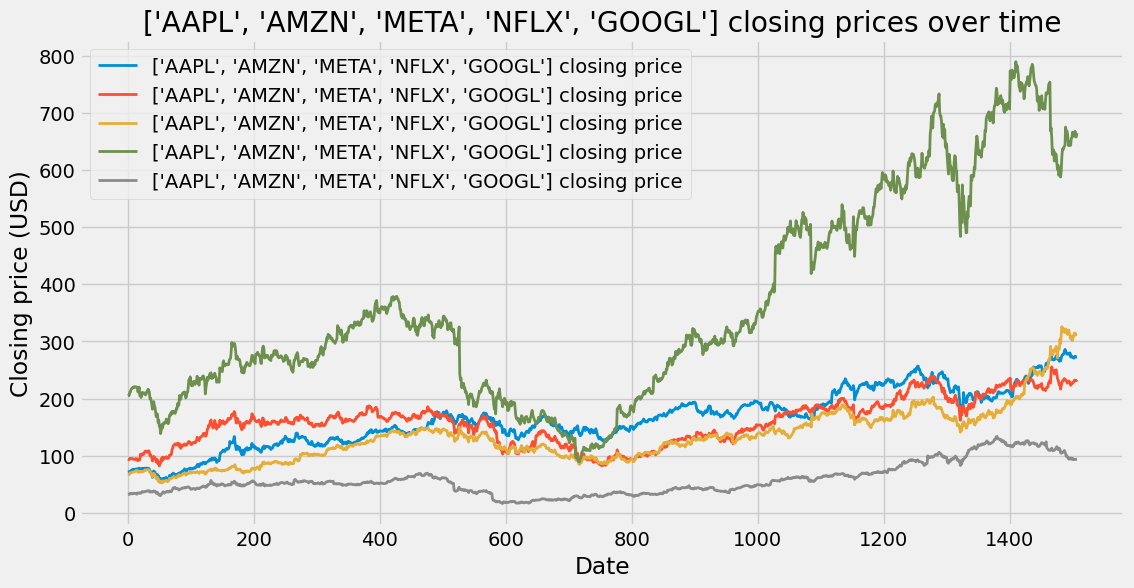

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label = f'{stock} closing price', linewidth = 2)
plt.title(f'{stock} closing prices over time')
plt.xlabel('Date')
plt.ylabel('Closing price (USD)')
plt.legend()
plt.show()

In [22]:
temp = [10,20,30,40,50,60,70,80,90]
print(sum(temp[1:6])/5)

40.0


In [23]:
df1 = pd.DataFrame(temp)
for el in range(len(df1)-5+1):
    el = el+5
    avg = sum(temp[el-5 : el])/5
    print(avg)

30.0
40.0
50.0
60.0
70.0


In [24]:
df1.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [25]:
ma100 = df['Close'].rolling(100).mean()
ma100
ma250 = df['Close'].rolling(250).mean()
ma250

Ticker,AAPL,AMZN,GOOGL,META,NFLX
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1503,231.245536,217.52700,208.432757,666.728086,109.654840
1504,231.307663,217.54888,208.907115,666.975221,109.663064
1505,231.384874,217.58216,209.392981,667.218075,109.676644
1506,231.472854,217.62708,209.886059,667.524087,109.691592


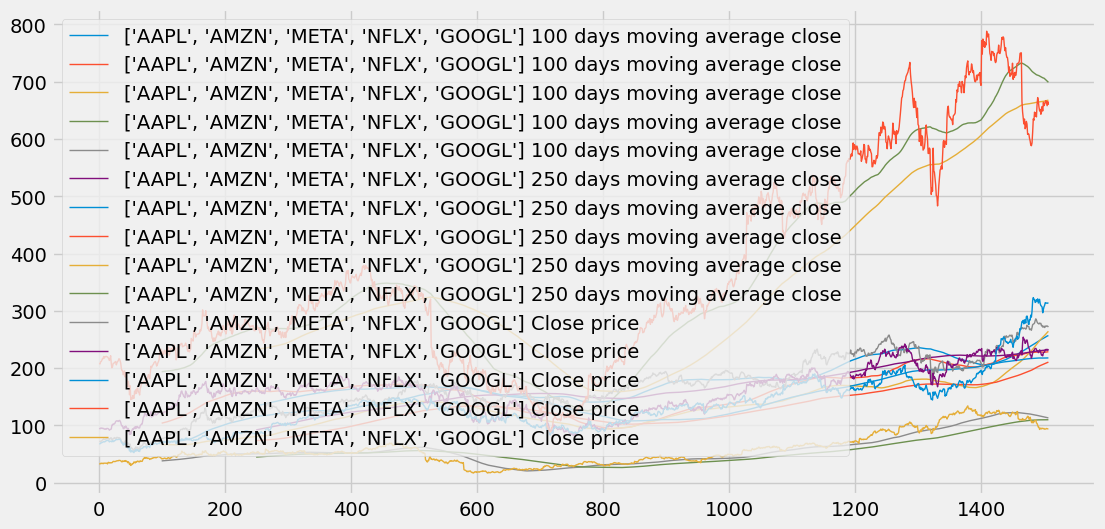

In [26]:
plt.figure(figsize=(12,6))
plt.plot(ma100, label = f'{stock} 100 days moving average close', linewidth=1)
plt.plot(ma250, label = f'{stock} 250 days moving average close', linewidth=1)
plt.plot(df['Close'], label = f'{stock} Close price', linewidth=1)
plt.legend()
plt.show()

In [27]:
ema100 = df.Close.ewm(span=100, adjust=False).mean()
ema200 = df.Close.ewm(span=200, adjust=False).mean()

In [28]:
df.pct_change()

Price      Close                                              High            \
Ticker      AAPL      AMZN     GOOGL      META      NFLX      AAPL      AMZN   
0            NaN       NaN       NaN       NaN       NaN       NaN       NaN   
1      -0.009722 -0.012139 -0.005231 -0.005291 -0.011855 -0.000066 -0.006222   
2       0.007968  0.014886  0.026654  0.018834  0.030469 -0.002063  0.009273   
3      -0.004703  0.002092 -0.001932  0.002164 -0.015127  0.003134  0.005358   
4       0.016086 -0.007809  0.007118  0.010138  0.025729  0.011765 -0.001510   
...          ...       ...       ...       ...       ...       ...       ...   
1503    0.005324  0.001034 -0.000827  0.003925  0.001497  0.010752  0.002151   
1504   -0.001497  0.000602 -0.001847 -0.006382  0.008864 -0.000218  0.000172   
1505    0.001317 -0.001935  0.000159 -0.006935 -0.003387 -0.003668 -0.001674   
1506   -0.002484  0.001982  0.000925  0.011022 -0.003930 -0.001021  0.000731   
1507   -0.004468 -0.007354 -0.002708 -0.008799 -0.000213 -0.001459  0.000945   

Price                                 ...      Open                      \
Ticker     GOOGL      META      NFLX  ...      AAPL      AMZN     GOOGL   
0            NaN       NaN       NaN  ...       NaN       NaN       NaN   
1       0.003705  0.002907 -0.000364  ...  0.003072 -0.005600 -0.000304   
2       0.017885  0.011312  0.019705  ... -0.011308 -0.002413  0.002693   
3       0.003704  0.008459  0.001011  ...  0.020593  0.023925  0.036127   
4       0.005950  0.007736  0.017820  ... -0.008938 -0.003392 -0.004027   
...          ...       ...       ...  ...       ...       ...       ...   
1503    0.000444  0.003273 -0.001386  ...  0.005538  0.013403  0.016600   
1504    0.000032  0.001152  0.010781  ...  0.006683 -0.000388 -0.000921   
1505   -0.003396 -0.013006  0.002957  ... -0.005362 -0.000431 -0.009889   
1506    0.009331  0.018129 -0.010319  ...  0.000440 -0.003147  0.003629   
1507   -0.007478 -0.010741  0.003405  ...  0.000916  0.007353  0.001120   

Price                         Volume                                          
Ticker      META      NFLX      AAPL      AMZN     GOOGL      META      NFLX  
0            NaN       NaN       NaN       NaN       NaN       NaN       NaN  
1       0.002225  0.002085  0.080029 -0.065674 -0.141873 -0.073586 -0.151344  
2      -0.002461 -0.011200 -0.190918  0.079003  0.997949  0.524695  0.487588  
3       0.029608  0.041316 -0.080374 -0.004161 -0.265951 -0.125829 -0.169501  
4       0.000846 -0.014801  0.213160 -0.132735  0.028663 -0.096390  0.510567  
...          ...       ...       ...       ...       ...       ...       ...  
1503    0.003757 -0.003105 -0.395770 -0.609291 -0.603692 -0.336911 -0.520088  
1504    0.008347  0.003974  0.201624  0.400525  0.079387  0.267668  0.775706  
1505   -0.015044  0.005456  0.101915  0.237779  0.800330  0.192422  0.109904  
1506    0.001033 -0.005001 -0.066438  0.106708 -0.114205  0.080056 -0.043754  
1507    0.009200  0.000855  0.232796  0.112877 -0.057719 -0.135739  0.003125  

[1508 rows x 25 columns]

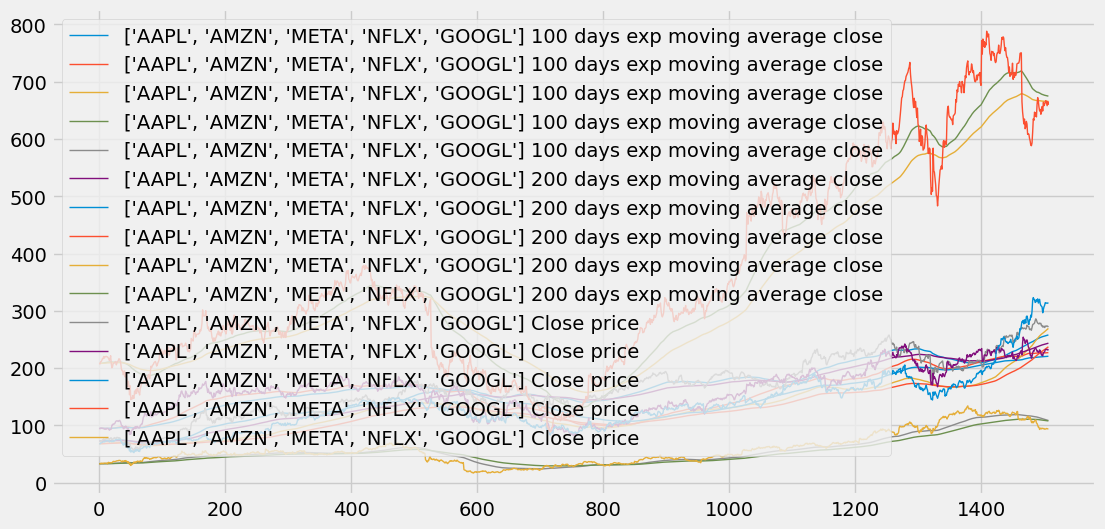

In [29]:
plt.figure(figsize=(12,6))
plt.plot(ema100, label = f'{stock} 100 days exp moving average close', linewidth=1)
plt.plot(ema200, label = f'{stock} 200 days exp moving average close', linewidth=1)
plt.plot(df['Close'], label = f'{stock} Close price', linewidth=1)
plt.legend()
plt.show()

In [ ]:
#Pentru crearea modelului trebuie sa impartim set-ul de date in 2 categorii:
#Date de training care reprezita in jur de 70-80% din set-ul de date;
#Date de testing care reprezinta in jur de 20-30% din set-ul de date.

In [30]:
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df['Close'][0:int(len(df)*0.3)])
data_training

Ticker,AAPL,AMZN,GOOGL,META,NFLX
0,72.400513,94.900497,67.873024,208.146591,32.980999
1,71.696655,93.748497,67.517975,207.045197,32.590000
2,72.267921,95.143997,69.317596,210.944626,33.583000
3,71.928047,95.343002,69.183693,211.401031,33.075001
4,73.085106,94.598503,69.676132,213.544220,33.925999
...,...,...,...,...,...
1050,167.594742,173.509995,130.322845,492.749481,59.769001
1051,167.475800,176.820007,133.278458,508.741119,60.851002
1052,169.190201,175.350006,134.300018,502.543152,60.481998
1053,171.192001,171.960007,136.541489,480.333679,60.092999


In [31]:
data_training.shape

(1055, 5)

In [32]:
from sklearn.preprocessing import MinMaxScaler

In [33]:
scaler = MinMaxScaler(feature_range = (0, 1))

In [34]:
data_training_array = scaler.fit_transform(data_training)

In [35]:
data_training_array

array([[0.12820362, 0.1248729 , 0.15602132, 0.28518954, 0.31112465],
       [0.12324197, 0.11387533, 0.15247002, 0.28257044, 0.30368159],
       [0.12726896, 0.12719746, 0.17047034, 0.29184324, 0.32258435],
       ...,
       [0.81049626, 0.89288366, 0.82044288, 0.9852613 , 0.83463412],
       [0.82460741, 0.86052105, 0.8428627 , 0.93244742, 0.82722911],
       [0.82796057, 0.89326546, 0.85109639, 0.97061702, 0.84655073]])

In [36]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100 : i])
    y_train.append(data_training_array[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)
x_train

array([[[0.12820362, 0.1248729 , 0.15602132, 0.28518954, 0.31112465],
        [0.12324197, 0.11387533, 0.15247002, 0.28257044, 0.30368159],
        [0.12726896, 0.12719746, 0.17047034, 0.29184324, 0.32258435],
        ...,
        [0.15897995, 0.38679529, 0.17490464, 0.33617777, 0.51374402],
        [0.16246395, 0.3820889 , 0.17812391, 0.34448302, 0.50055205],
        [0.15877504, 0.37491949, 0.18215644, 0.33808888, 0.47285468]],

       [[0.12324197, 0.11387533, 0.15247002, 0.28257044, 0.30368159],
        [0.12726896, 0.12719746, 0.17047034, 0.29184324, 0.32258435],
        [0.12487311, 0.12909727, 0.169131  , 0.29292857, 0.31291407],
        ...,
        [0.16246395, 0.3820889 , 0.17812391, 0.34448302, 0.50055205],
        [0.15877504, 0.37491949, 0.18215644, 0.33808888, 0.47285468],
        [0.1611319 , 0.36944456, 0.18161569, 0.33086891, 0.48260107]],

       [[0.12726896, 0.12719746, 0.17047034, 0.29184324, 0.32258435],
        [0.12487311, 0.12909727, 0.169131  , 0.29292857, 0.3

In [41]:
model = Sequential()
x_train.shape

(955, 100, 5)

In [48]:
from keras.layers import Input, LSTM, Dropout, Dense

model = Sequential()
model.add(Input(shape=(x_train.shape[1], x_train.shape[2])))
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

In [49]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 100, 50)        │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,561 (701.41 KB)

 Trainable params: 179,561 (701.41 KB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 801ms/step - loss: 0.1362
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 773ms/step - loss: 0.0231
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 782ms/step - loss: 0.0197
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 937ms/step - loss: 0.0186
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 792ms/step - loss: 0.0147
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 823ms/step - loss: 0.0145
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 792ms/step - loss: 0.0143
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 828ms/step - loss: 0.0144
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 866ms/step - loss: 0.0137
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 971ms/step - loss: 0.0128
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 867ms/step - loss: 0.0129
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 25s 805ms/step - loss: 0.0129
Epoch 13/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 800ms/step - loss: 0.0118
Epoch 14/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 819ms/step - loss: 0.0139
Epoch 15/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 

In [52]:
past_100_days = data_training.tail(100)
final_df = pd.concat([past_100_days, data_testing], ignore_index = True)
input_data = scaler.transform(final_df)
input_data

array([[0.84301343, 0.4420982 , 0.84573964, 0.53810142, 0.34230565],
       [0.84036578, 0.44467564, 0.84365619, 0.52828604, 0.4481078 ],
       [0.82238958, 0.41384051, 0.82232777, 0.5184706 , 0.44656594],
       ...,
       [0.58840738, 0.78657389, 0.8419897 , 0.5559626 , 0.88211001],
       [0.608038  , 0.79401053, 0.87739542, 0.56537695, 0.88980055],
       [0.61547714, 0.84611537, 0.87954786, 0.55648184, 0.87931165]])

In [53]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100 : i])
    y_test.append(input_data[i, 0])
x_test, y_test = np.array(x_test), np.array(y_test)
x_test

array([[[0.84301343, 0.4420982 , 0.84573964, 0.53810142, 0.34230565],
        [0.84036578, 0.44467564, 0.84365619, 0.52828604, 0.4481078 ],
        [0.82238958, 0.41384051, 0.82232777, 0.5184706 , 0.44656594],
        ...,
        [0.81049626, 0.89288366, 0.82044288, 0.9852613 , 0.83463412],
        [0.82460741, 0.86052105, 0.8428627 , 0.93244742, 0.82722911],
        [0.82796057, 0.89326546, 0.85109639, 0.97061702, 0.84655073]],

       [[0.84036578, 0.44467564, 0.84365619, 0.52828604, 0.4481078 ],
        [0.82238958, 0.41384051, 0.82232777, 0.5184706 , 0.44656594],
        [0.82322588, 0.42711013, 0.83125605, 0.53111745, 0.45775906],
        ...,
        [0.82460741, 0.86052105, 0.8428627 , 0.93244742, 0.82722911],
        [0.82796057, 0.89326546, 0.85109639, 0.97061702, 0.84655073],
        [0.12820362, 0.1248729 , 0.15602132, 0.28518954, 0.31112465]],

       [[0.82238958, 0.41384051, 0.82232777, 0.5184706 , 0.44656594],
        [0.82322588, 0.42711013, 0.83125605, 0.53111745, 0.4

In [54]:
x_test.shape

(452, 100, 5)

In [55]:
y_predicted = model.predict(x_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 629ms/step


In [56]:
y_predicted

array([[0.75648415],
       [0.7470094 ],
       [0.7342075 ],
       [0.71805096],
       [0.69911814],
       [0.6781851 ],
       [0.65566707],
       [0.6321969 ],
       [0.60846996],
       [0.5851602 ],
       [0.5628995 ],
       [0.5417541 ],
       [0.52058476],
       [0.49853653],
       [0.47514728],
       [0.45016536],
       [0.42368865],
       [0.3972696 ],
       [0.37235427],
       [0.3500635 ],
       [0.33134136],
       [0.31615347],
       [0.30445254],
       [0.2953498 ],
       [0.28816006],
       [0.28243262],
       [0.27778125],
       [0.2739498 ],
       [0.27077425],
       [0.26812616],
       [0.2658815 ],
       [0.2639638 ],
       [0.2623138 ],
       [0.26088515],
       [0.25963923],
       [0.258541  ],
       [0.25755453],
       [0.2566456 ],
       [0.25578228],
       [0.25492892],
       [0.25405538],
       [0.2531462 ],
       [0.25219202],
       [0.25119263],
       [0.25014898],
       [0.24905717],
       [0.2479142 ],
       [0.246

In [57]:
scaler.scale_

array([0.00704923, 0.00954649, 0.01000228, 0.00237799, 0.01903602])

In [58]:
scaler_factor = 1 / 0.00729727
print(scaler_factor)

137.03754965898207


In [59]:
y_test = y_test * scaler_factor
y_predicted = y_predicted * scaler_factor

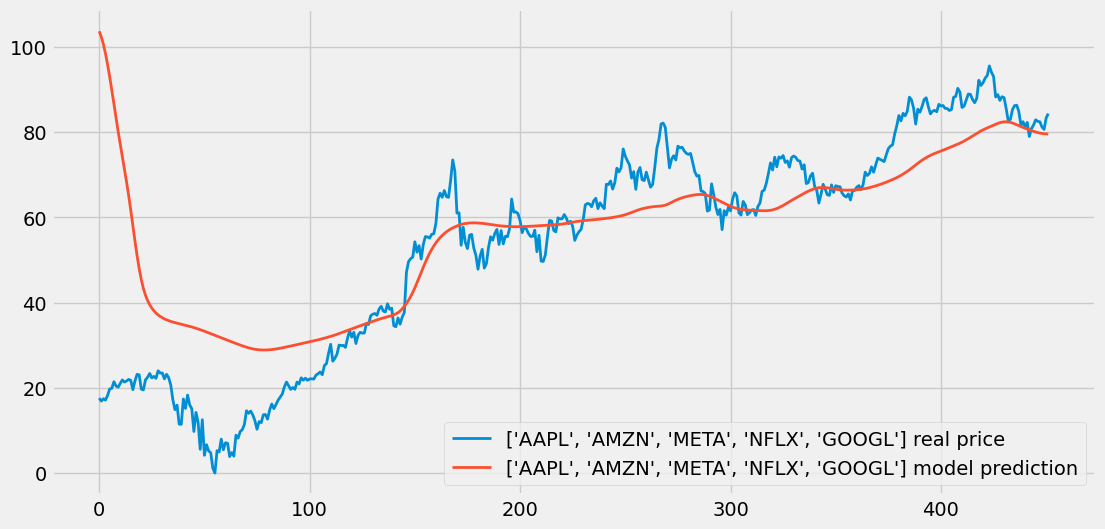

In [60]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label = f'{stock} real price', linewidth=2)
plt.plot(y_predicted, label = f'{stock} model prediction', linewidth=2)
plt.legend()
plt.show()

In [61]:
model.save('stock_dl_model.h5')